In [4]:
!pip install pyspark --quiet
print("PySpark installation complete")

PySpark installation complete


In [5]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round

import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

spark=SparkSession.builder \
      .appName('Day4_Bigdata_sales') \
      .config('spark.sql.adaptive.enabled', 'true') \
      .getOrCreate()

print(f'Spark version: {spark.version}')
print(f'SparkSession : ACTIVE')

Spark version: 4.0.2
SparkSession : ACTIVE


In [6]:
df_bronze=spark.read \
   .option('header','true') \
   .option('inferSchema','true') \
   .csv('large_sales_data.csv')

print('=== BRONZE LAYER - Raw Data ===')
print(f'Rows : {df_bronze.count()}')
print(f'Columns : {len(df_bronze.columns)}')
print(f'Names : {df_bronze.columns}')
print()
df_bronze.printSchema()

=== BRONZE LAYER - Raw Data ===
Rows : 5000
Columns : 13
Names : ['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [7]:
print('First 5 rows:')
df_bronze.show(5,truncate=False)
print('\nBasic statistics for numeric columns:')
df_bronze.select('quantity','unit_price','revenue').describe().show()

First 5 rows:
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Ku

In [8]:
df_bronze.write \
   .mode('overwrite') \
   .parquet('sales_bronze.parquet')

print('Bronze Parquet saved: sales_bronze.parquet')

import os

def get_dir_size(path):
  if os.path.isfile(path):
    return os.path.getsize(path)/1024

  total=0
  for dirpath,dirnames,filenames in os.walk(path):
    for f in filenames:
      total+=os.path.getsize(os.path.join(dirpath,f))
  return total / 1024

csv_size= get_dir_size('large_sales_data.csv')
parquet_size= get_dir_size('sales_bronze.parquet')
reduction=(1-parquet_size/csv_size)*100

print(f'\nCSV size : {csv_size:.1f} KB')
print(f'Parquet size : {parquet_size:.1f} KB')
print(f'Reduction : {reduction:.1f}% smaller')
print(f'\nAt 1 TB scale: CSV=1000 GB -> Parquet={1000*(1-reduction/100):.0f} GB')

Bronze Parquet saved: sales_bronze.parquet

CSV size : 529.3 KB
Parquet size : 55.1 KB
Reduction : 89.6% smaller

At 1 TB scale: CSV=1000 GB -> Parquet=104 GB


In [9]:
df_silver=df_bronze \
   .dropDuplicates() \
   .dropna(subset=['order_id','product','revenue'])

df_silver=df_silver.withColumn(
    'order_date',
    to_date(col('order_date'),'yyyy-MM-dd')
)

df_silver=df_silver \
    .withColumn('order_year', year(col('order_date'))) \
    .withColumn('order_month', month(col('order_date')))

df_silver=df_silver.withColumn(
    'revenue_category',
    F.when(col('revenue')>40000, 'High')
    .when(col('revenue')>10000, 'Medium')
    .otherwise('Low')
)

print(f'Silver Layer rows: {df_silver.count()}')
print(f'New columns added : order_year, order_month, revenue_category')
df_silver.select('product','revenue','order_year','order_month','revenue_category').show()

Silver Layer rows: 5000
New columns added : order_year, order_month, revenue_category
+----------+-------+----------+-----------+----------------+
|   product|revenue|order_year|order_month|revenue_category|
+----------+-------+----------+-----------+----------------+
|  Keyboard|  13200|      2023|          2|          Medium|
|    Webcam|  17500|      2023|          1|          Medium|
|   Speaker|  58500|      2023|          4|            High|
|  Keyboard|   9600|      2023|         12|             Low|
|    Laptop| 180000|      2023|          8|            High|
|Headphones|  38500|      2023|          5|          Medium|
|    Webcam|  35000|      2023|         11|          Medium|
|    Laptop| 360000|      2023|          1|            High|
|    Tablet| 320000|      2023|          6|            High|
|    Laptop| 225000|      2023|          6|            High|
|     Mouse|   6400|      2023|          8|             Low|
|   Monitor| 132000|      2023|          7|            High|

In [10]:
df_silver.write \
   .mode('overwrite') \
   .parquet('sales_silver.parquet')

print('Silver Parquet saved: sales_silver.parquet')
print(f'Silver size: {get_dir_size("sales_silver.parquet"):.1f} KB')

df_verify= spark.read.parquet('sales_silver.parquet')
print('\n=== Verify Silver layer ===')
print(f'Read-back rows: {df_verify.count()} (should match Silver count)')
df_verify.printSchema()

Silver Parquet saved: sales_silver.parquet
Silver size: 59.8 KB

=== Verify Silver layer ===
Read-back rows: 5000 (should match Silver count)
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



In [11]:
top_products=df_silver \
   .groupBy('product') \
   .agg(
       F.sum('revenue').alias('total_revenue'),
       F.count('order_id').alias('num_orders'),
       F.avg('revenue').alias('avg_order_revenue')
   ) \
   .orderBy('total_revenue', ascending=False) \
   .limit(5)

print('=== Top 5 Products by Revenue ===')
top_products.show(truncate=False)

=== Top 5 Products by Revenue ===
+-------+-------------+----------+------------------+
|product|total_revenue|num_orders|avg_order_revenue |
+-------+-------------+----------+------------------+
|Laptop |182700000    |502       |363944.22310756973|
|Tablet |135104000    |532       |253954.8872180451 |
|Monitor|82126000     |481       |170740.12474012474|
|Printer|44544000     |488       |91278.68852459016 |
|Speaker|16317000     |470       |34717.02127659575 |
+-------+-------------+----------+------------------+



In [12]:
regions=df_silver \
   .groupBy('region') \
   .agg(
       F.sum('revenue').alias('total_revenue'),
       F.count('order_id').alias('total_orders'),
       F.count_distinct('customer_name').alias('unique_customers')
   ) \
   .orderBy('total_revenue', ascending=False) \
   .limit(5)

print('=== Revenue by Region ===')
regions.show(truncate=False)


=== Revenue by Region ===
+------+-------------+------------+----------------+
|region|total_revenue|total_orders|unique_customers|
+------+-------------+------------+----------------+
|West  |198275600    |2021        |15              |
|South |147145900    |1483        |15              |
|North |99878400     |995         |15              |
|East  |50547700     |501         |15              |
+------+-------------+------------+----------------+



In [13]:
monthly_trend=df_silver \
   .withColumn('month_name', F.date_format(F.col('order_date'), 'MMM')) \
   .groupBy('order_month','month_name') \
   .agg(
       F.sum('revenue').alias('monthly_revenue'),
       F.count('order_id').alias('monthly_orders'),
   ) \
   .orderBy('order_month')

print('=== Monthly Revenue trend ===')
monthly_trend.show(truncate=False)

=== Monthly Revenue trend ===
+-----------+----------+---------------+--------------+
|order_month|month_name|monthly_revenue|monthly_orders|
+-----------+----------+---------------+--------------+
|1          |Jan       |41068200       |423           |
|2          |Feb       |34485400       |375           |
|3          |Mar       |40031200       |451           |
|4          |Apr       |38857100       |390           |
|5          |May       |39984500       |423           |
|6          |Jun       |40707400       |390           |
|7          |Jul       |42640700       |405           |
|8          |Aug       |43718500       |418           |
|9          |Sep       |37640200       |398           |
|10         |Oct       |47839000       |479           |
|11         |Nov       |44577100       |419           |
|12         |Dec       |44298300       |429           |
+-----------+----------+---------------+--------------+



In [14]:
gold_region=regions
gold_region.write.mode('overwrite').parquet('gold_region_revenue.parquet')
print('Gold 1 saved: gold_region_revenue.parquet')

gold_products=df_silver \
    .groupBy('product','category') \
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('units_sold'),
        spark_round(F.avg('quantity'),1).alias('avg_quantity_per_order'),
        F.max('revenue').alias('largest_order')
    ) \
    .orderBy('total_revenue', ascending=False) \

gold_products.write.mode('overwrite').parquet('gold_product_summary.parquet')
print('Gold 2 saved: gold_product_summary.parquet')

gold_monthly=monthly_trend
gold_monthly.write.mode('overwrite').parquet('gold_monthly_trend.parquet')
print('Gold 3 saved: gold_monthly_trend.parquet')

Gold 1 saved: gold_region_revenue.parquet
Gold 2 saved: gold_product_summary.parquet
Gold 3 saved: gold_monthly_trend.parquet


In [15]:
region_pd=spark.read.parquet('gold_region_revenue.parquet').toPandas()
product_pd=spark.read.parquet('gold_product_summary.parquet').toPandas()
monthly_pd=spark.read.parquet('gold_monthly_trend.parquet').toPandas()

In [16]:
region_pd.head(5)

,region,total_revenue,total_orders,unique_customers
0,West,198275600,2021,15
1,South,147145900,1483,15
2,North,99878400,995,15
3,East,50547700,501,15


In [17]:
product_pd.head(5)

,product,category,total_revenue,units_sold,avg_quantity_per_order,largest_order
0,Laptop,Electronics,182700000,502,8.1,675000
1,Tablet,Electronics,135104000,532,7.9,480000
2,Monitor,Electronics,82126000,481,7.8,330000
3,Printer,Electronics,44544000,488,7.6,180000
4,Speaker,Electronics,16317000,470,7.7,67500


In [18]:
monthly_pd.head(5)

,order_month,month_name,monthly_revenue,monthly_orders
0,1,Jan,41068200,423
1,2,Feb,34485400,375
2,3,Mar,40031200,451
3,4,Apr,38857100,390
4,5,May,39984500,423


In [19]:
region_pd= region_pd.sort_values(by='total_revenue',ascending=False)
product_pd= product_pd.sort_values(by='total_revenue',ascending=False)
monthly_pd= monthly_pd.sort_values(by='order_month')

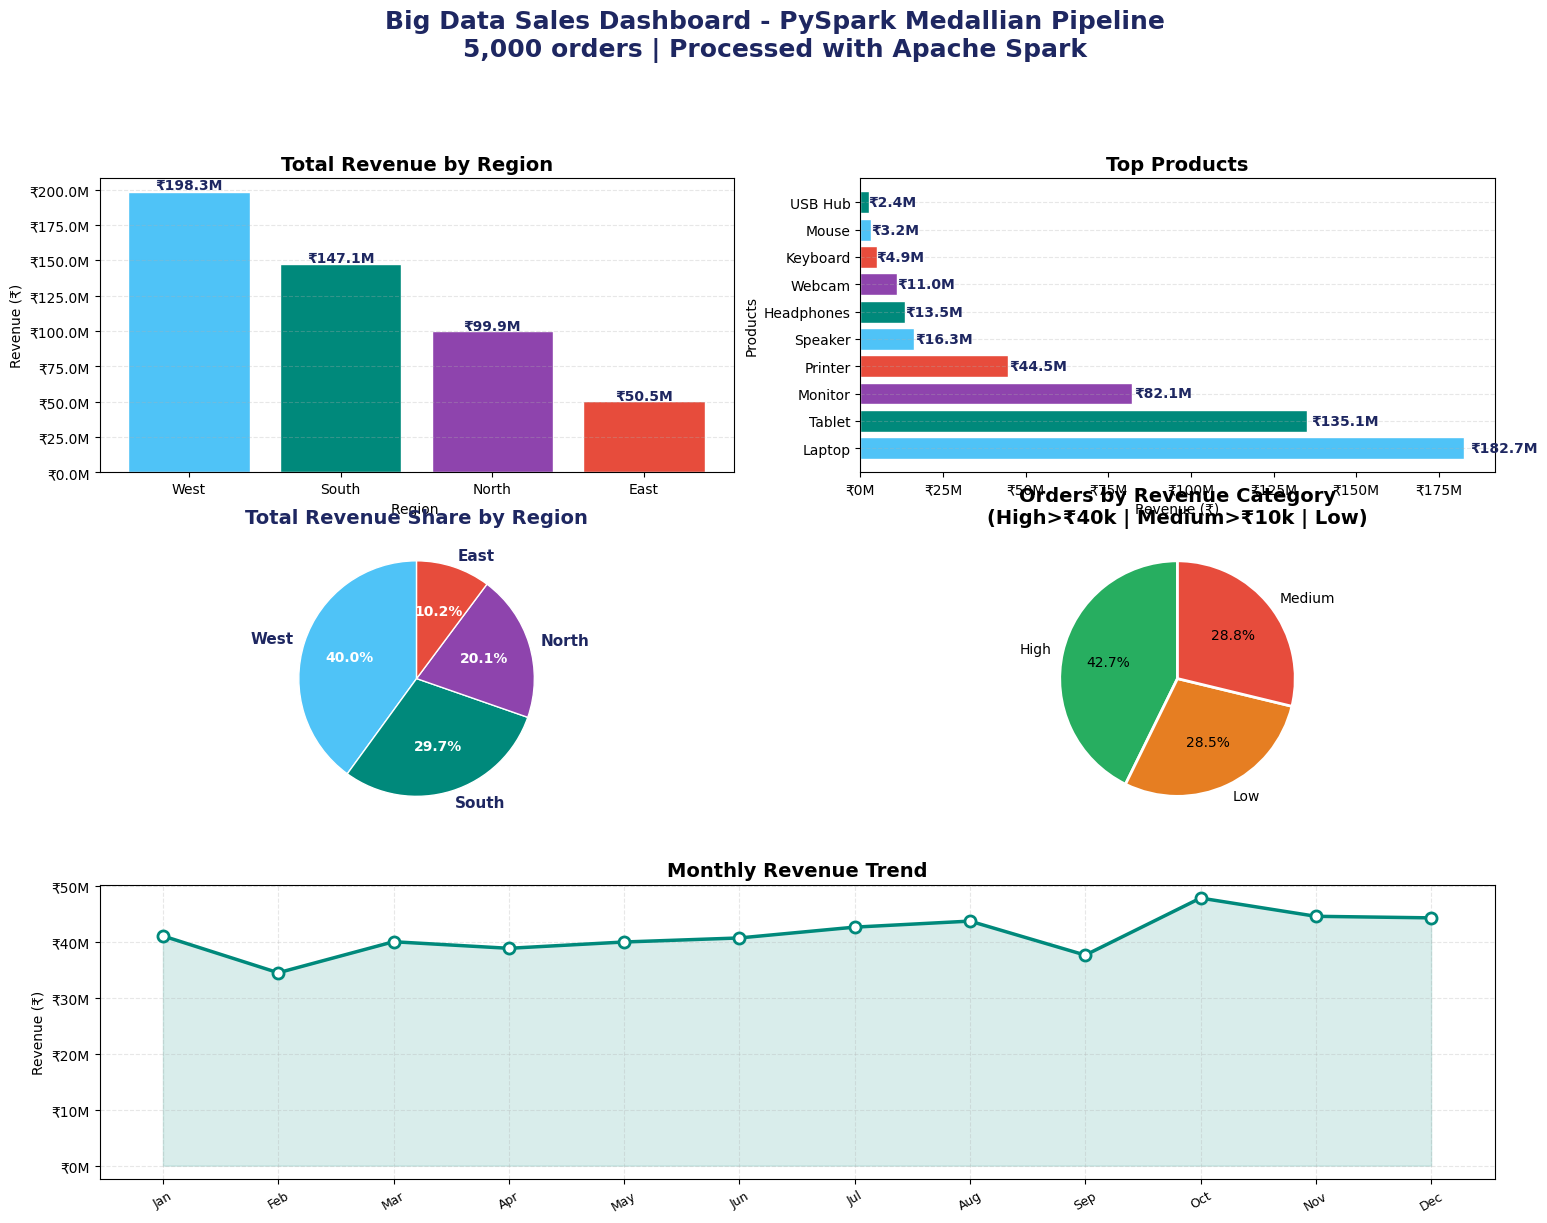

In [21]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18,13))
gs = gridspec.GridSpec(3, 2, figure=fig)

fig.suptitle(
    'Big Data Sales Dashboard - PySpark Medallian Pipeline\n'
    '5,000 orders | Processed with Apache Spark',
    fontsize=18, fontweight='bold', color='#1E2761', y=1.01
)

colors4= ['#4FC3F7','#00897B','#8E44AD','#E74C3C']

ax1 = fig.add_subplot(gs[0, 0])
bars1= ax1.bar(region_pd['region'],region_pd['total_revenue'],
               color=colors4[:len(region_pd)],edgecolor='white')

for bar in bars1:
  ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
           f'₹{bar.get_height()/1e6:.1f}M',
           ha='center',fontsize=10,fontweight='bold',color='#1E2761')

ax1.set_title('Total Revenue by Region',fontsize=14,fontweight='bold')
ax1.set_ylabel('Revenue (₹)')
ax1.set_xlabel('Region ')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax1.grid(axis='y', linestyle='--', alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
bars2= ax2.barh(product_pd['product'],product_pd['total_revenue'],
               color=colors4[:len(product_pd)],edgecolor='white')

for bar in bars2:
  ax2.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
           f'₹{bar.get_width()/1e6:.1f}M',
           va='center',fontsize=10,fontweight='bold',color='#1E2761')

ax2.set_title('Top Products',fontsize=14,fontweight='bold')
ax2.set_ylabel('Products')
ax2.set_xlabel('Revenue (₹)')
ax2.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.0f}M')
)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

ax3 = fig.add_subplot(gs[1, 0])
wedges, texts, autotexts = ax3.pie(
    region_pd['total_revenue'],
    labels=region_pd['region'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors4[:len(region_pd)],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

plt.setp(autotexts, size=10, weight="bold", color="white")
plt.setp(texts, size=11, fontweight='bold', color='#1E2761')
ax3.set_title('Total Revenue Share by Region', fontsize=14, fontweight='bold', color='#1E2761')

ax4 = fig.add_subplot(gs[1, 1])
rev_cat= df_silver.groupBy('revenue_category') \
    .count().orderBy('revenue_category').toPandas()
ax4.pie(rev_cat['count'],
        labels=rev_cat['revenue_category'],
        colors=['#27AE60','#E67E22','#E74C3C'],
        autopct='%1.1f%%',startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})


ax4.set_title('Orders by Revenue Category\n(High>₹40k | Medium>₹10k | Low)',fontsize=14,fontweight='bold')

ax5 = fig.add_subplot(gs[2, :])
month_names=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_labels=[month_names[m-1] for m in monthly_pd['order_month']]

ax5.plot(monthly_labels,monthly_pd['monthly_revenue'],
         marker='o',linewidth=2.5,color='#00897B',
         markersize=8,markerfacecolor='white',markeredgewidth=2)
ax5.fill_between(range(len(monthly_labels)),
                 monthly_pd['monthly_revenue'],
                 alpha=0.15,color='#00897B')
ax5.set_title('Monthly Revenue Trend',fontsize=14,fontweight='bold')
ax5.set_ylabel('Revenue (₹)')
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.0f}M'))
ax5.grid(alpha=0.3,linestyle='--')
ax5.tick_params(axis='x',rotation=30,labelsize=9)